In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
    # 1 = Male, 0 = Female
}

df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [15]:
# Step 3: Standardizing the Data

X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized Data:")
print(X_scaled)

Standardized Data:
[[ 0.18419807  0.13867505  0.50910379]
 [-0.52425605 -0.69337525 -0.59764358]
 [ 1.60110632  1.52542554  1.61585117]
 [ 0.8926522   0.5547002   0.06640484]
 [-1.23271018 -1.24807544 -1.26169201]
 [ 0.46757972  0.83205029  0.95180275]
 [-0.09918358 -0.2773501  -0.15494463]
 [ 1.17603385  1.38675049  1.17315222]
 [-0.94932853 -0.83205029 -0.81899306]
 [-1.51609183 -1.38675049 -1.48304149]]


In [4]:
# Step 4: Applying PCA Algorithm

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Transformed Data:")
print(X_pca)

PCA Transformed Data:
[[ 0.90005784  0.63516169]
 [-1.3998906  -0.38005711]
 [ 2.88165429 -0.44045863]
 [ 1.24720863  0.46035914]
 [-2.37553282  0.15965573]
 [ 1.62063399  0.25901251]
 [-0.7496539  -0.73608984]
 [ 2.37324514 -0.1473138 ]
 [-1.79678422 -0.15360555]
 [-2.70093834  0.34333585]]


In [5]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

In [6]:
# Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

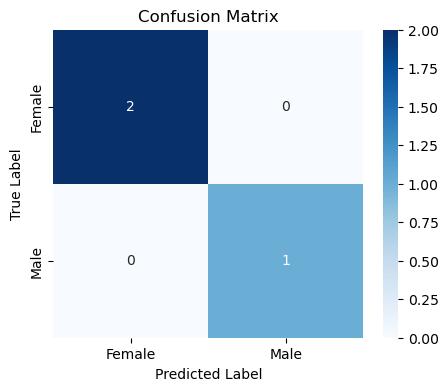

In [7]:
# Step 5: Evaluating with Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [8]:
# Step 6: Visualizing PCA Result

y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

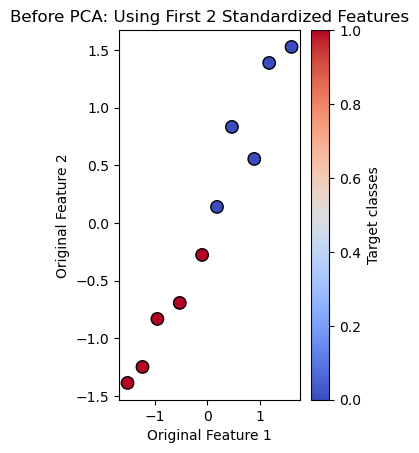

In [9]:
# Before PCA

plt.subplot(1, 2, 1)

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

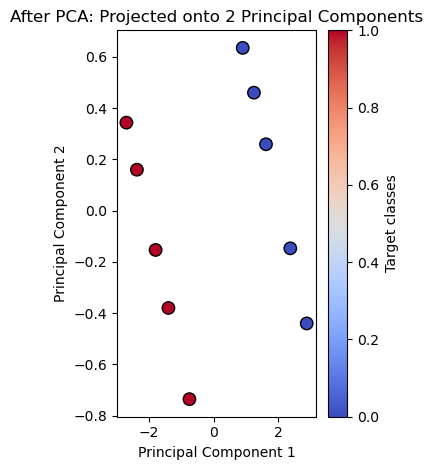

In [10]:
# After PCA

plt.subplot(1, 2, 2)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

In [11]:
# Step 7: Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"Principal Component {i}: {variance * 100:.2f}%")

Explained Variance Ratio:
Principal Component 1: 94.04%
Principal Component 2: 4.38%


In [12]:
# Step 8: Cumulative Explained Variance

cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Explained Variance:")
for i, variance in enumerate(cumulative_variance, start=1):
    print(f"First {i} Component(s): {variance * 100:.2f}%")


Cumulative Explained Variance:
First 1 Component(s): 94.04%
First 2 Component(s): 98.42%


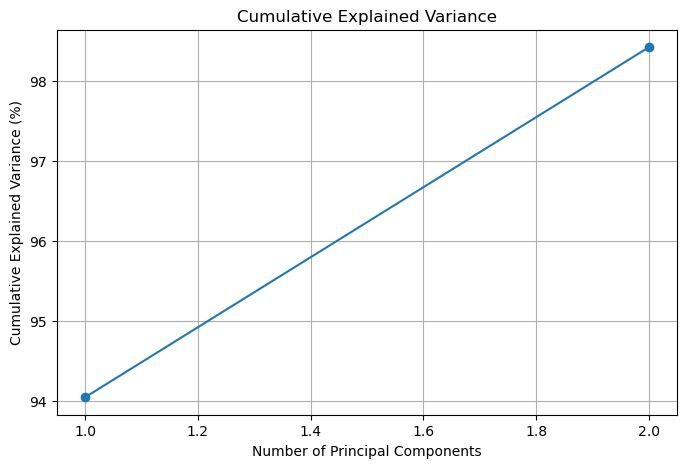

In [13]:
# Step 9: Plot Explained and Cumulative Variance

plt.figure(figsize=(8, 5))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(
    components,
    cumulative_variance * 100,
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')
plt.grid(True)

plt.show()

In [14]:
# Step 10: Display Principal Components

print("Principal Components:")
print(pca.components_)

print("\nEigenvalues / Variance:")
print(pca.explained_variance_)

Principal Components:
[[ 0.50453588  0.51136651  0.50379849  0.47972381]
 [-0.30186463 -0.22674555 -0.30130303  0.87560304]]

Eigenvalues / Variance:
[4.17962714 0.19459881]
